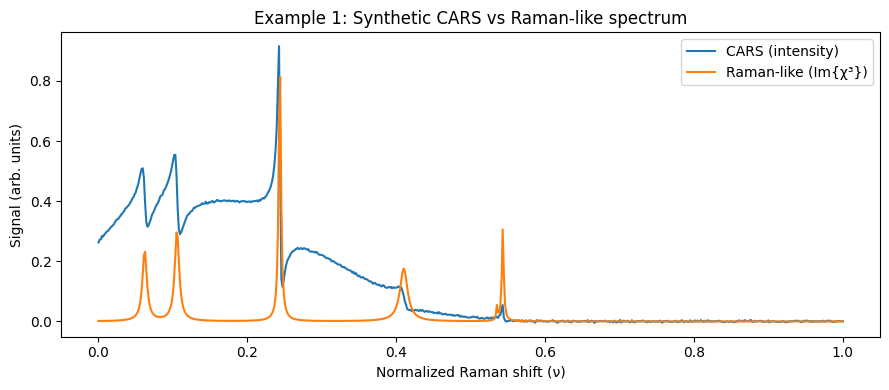

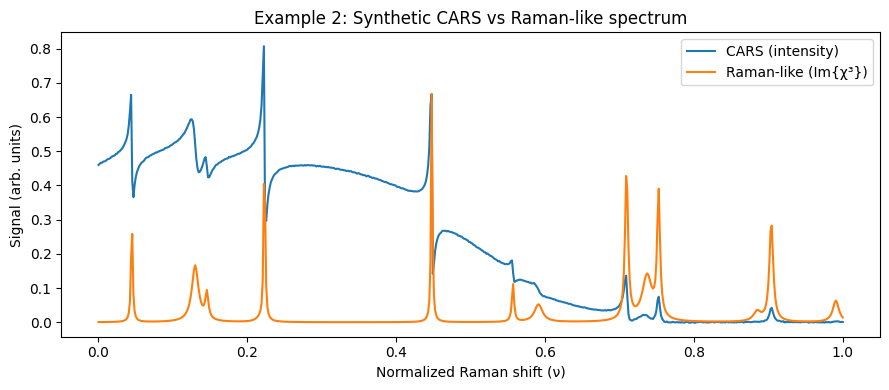

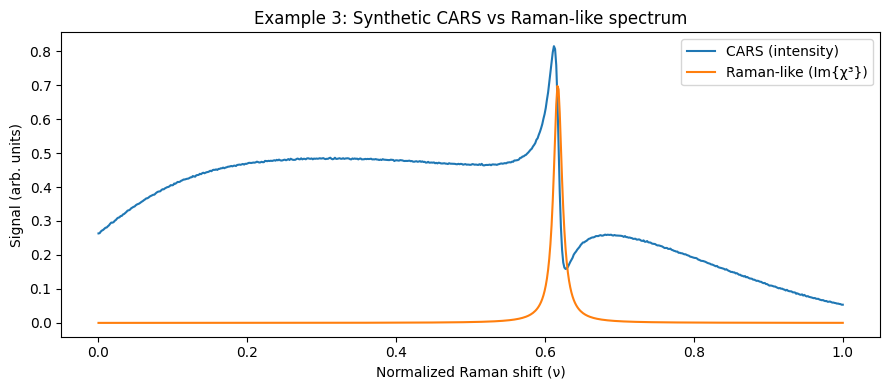

In [2]:
# --- Synthetic CARS vs Raman-like spectra (3 examples) ---
# Paste into one Jupyter cell and run.

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1) Global configuration
# ----------------------------
n_points = 640                          # samples per spectrum
nu = np.linspace(0, 1, n_points)        # normalized Raman-shift axis
max_features = 25                       # max Lorentzian peaks per spectrum
rng = np.random.default_rng(2000)       # set seed for reproducibility (change/remove if you want)

# ----------------------------
# 2) Physics-based generators
# ----------------------------
def random_chi3(rng):
    """
    Create random Lorentzian peak parameters (no NRB).
    Returns params with rows [amplitude a, center w, linewidth g].
    """
    n_lor = rng.integers(1, max_features)        # number of peaks
    a = rng.uniform(0, 1, n_lor)                 # amplitudes
    w = rng.uniform(0, 1, n_lor)                 # centers
    g = rng.uniform(0.001, 0.008, n_lor)         # widths (small)
    params = np.c_[a, w, g]                      # shape (n_lor, 3)
    return params

def build_chi3(params):
    """
    Build complex χ³(ν) as sum of Lorentzian responses, then normalize.
    χ³(ν) = Σ_k a_k / (w_k - ν - i g_k)
    Returns complex array (n_points,)
    """
    # broadcasting over (n_points, n_lor)
    denom = (-nu[:, None]) + params[:, 1] - 1j * params[:, 2]
    chi3 = np.sum(params[:, 0] / denom, axis=1)
    # normalize to max magnitude 1 so examples have comparable scale
    chi3 = chi3 / np.max(np.abs(chi3))
    return chi3

def sigmoid(x, c, b):
    """Logistic sigmoid with center c and slope b."""
    return 1.0 / (1.0 + np.exp(-(x - c) * b))

def generate_nrb(rng):
    """
    Make a smooth non-resonant background (NRB) as product of two sigmoids:
    one rising near c1 and one falling near c2.
    """
    bs = rng.normal(10, 5, 2)           # slopes
    c1 = rng.normal(0.2, 0.3)           # left edge
    c2 = rng.normal(0.7, 0.3)           # right edge
    sig1 = sigmoid(nu, c1,  bs[0])      # rising edge
    sig2 = sigmoid(nu, c2, -bs[1])      # falling edge
    nrb  = sig1 * sig2
    return nrb, (c1, c2), (bs[0], bs[1])

def get_spectrum(rng):
    """
    Produce one synthetic pair:
      cars  = (|χ³ + NRB|^2)/2 + noise      -> model input
      raman = Im{χ³}                         -> target
    Also returns some internals for debugging/inspection.
    """
    params = random_chi3(rng)
    chi3 = build_chi3(params) * rng.uniform(0.3, 1.0)       # random overall scale
    nrb, cs, bs = generate_nrb(rng)
    noise = rng.normal(0, 1, n_points) * rng.uniform(5e-4, 3e-3)

    cars = (np.abs(chi3 + nrb)**2) / 2.0 + noise            # synthetic CARS intensity
    raman = chi3.imag                                        # Raman-like spectrum

    return cars, raman, chi3, nrb, params, cs, bs

# ----------------------------
# 3) Make and plot 3 examples
# ----------------------------
for i in range(1, 4):
    cars, raman, chi3, nrb, params, cs, bs = get_spectrum(rng)

    plt.figure(figsize=(9, 4))
    plt.plot(nu, cars,  label="CARS (intensity)")
    plt.plot(nu, raman, label="Raman-like (Im{χ³})")
    plt.title(f"Example {i}: Synthetic CARS vs Raman-like spectrum")
    plt.xlabel("Normalized Raman shift (ν)")
    plt.ylabel("Signal (arb. units)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# (Optional) If you also want to see NRB and centers on the last example, uncomment:
# plt.figure(figsize=(9,4))
# plt.plot(nu, nrb, label="NRB (baseline)")
# for a, w, g in params:
#     plt.axvline(w, ls="--", lw=1)
# plt.title("Last example: NRB and peak centers (w)")
# plt.xlabel("Normalized Raman shift (ν)")
# plt.ylabel("NRB / markers")
# plt.legend(); plt.tight_layout(); plt.show()
